# Final Project_RTF: HuffPost News Category Classification
**Course:** Boston University Virtual — Module 7: Advanced Machine Learning & AI   
**Date:** April 14, 2026  
**Purpose:** Final clean implementation of best model selected from Milestone 2 experiments.

---

## A.1: Setup and Context

### Summary of Milestones 1 and 2

**Milestone 1** established the problem framing and dataset analysis. Key findings:
- Dataset: HuffPost News Category Dataset v2 — 200,853 articles, 
  originally 41 categories
- Task: Multi-class single-label text classification — predict news 
  category from headline + short description
- EDA revealed significant class imbalance (~32x ratio), ~10% missing 
  descriptions, and label ambiguity confirmed by t-SNE showing no clean 
  separation in text space
- Primary metric selected: Macro F1 (treats all classes equally)

**Milestone 2** explored three model architectures:
- Baseline: Embedding + GlobalAveragePooling — Val Acc 58.92%
- Custom: GloVe + BiLSTM + Dropout — Val Acc 65.12% (best)
- Transfer: DistilBERT (frozen) — Val Acc 60.56%

Key insight: Trainable GloVe embeddings + BiLSTM outperformed frozen 
DistilBERT, demonstrating that word order processing and fine-tuned 
embeddings matter more than model size for this task.

### Final Preprocessing Pipeline

**Cleaning steps:**
- Stripped whitespace from all text fields
- Removed 6 empty headlines
- Filled empty descriptions with empty string (headline-only for ~10%)
- Concatenated headline + [SEP] + description, lowercased
- Removed 491 duplicates → **200,356 final rows**

**Category merging (key improvement over Milestone 2):**
Merged 8 semantically overlapping categories identified in Milestone 2 
error analysis, reducing from 41 to 33 classes:
- WORLDPOST + THE WORLDPOST → WORLD NEWS
- TASTE → FOOD & DRINK  
- ARTS + CULTURE & ARTS → ARTS & CULTURE
- PARENTS → PARENTING
- STYLE → STYLE & BEAUTY
- HEALTHY LIVING → WELLNESS

**Tokenization:**
- TextVectorization: max_tokens=20,000, sequence_length=128
- Covers 95th percentile of combined text length

**Splits:** 80/10/10 stratified, random_seed=42  
- Train: 160,284 | Val: 20,036 | Test: 20,036

In [1]:

# --- Standard Libraries
import os
import time
import math
import random
import datetime
from datetime import datetime
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [2]:
# additional imports for framework compatibility
from datetime import datetime
from pathlib import Path
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, Dense, 
    Dropout, BatchNormalization, LSTM, Bidirectional
)
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

In [4]:
import os, zipfile, urllib.request
from pathlib import Path
import numpy as np
from tensorflow.keras.datasets import imdb

# -----------------------------
# GloVe Setup (auto-download)
# -----------------------------
GLOVE_DIR = Path(os.environ.get("GLOVE_DIR", "data/glove")).expanduser()
GLOVE_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_6B_URL = "https://nlp.stanford.edu/data/glove.6B.zip"

def ensure_glove_6b(download_dir: Path) -> Path:
    zip_path = download_dir / "glove.6B.zip"
    extracted_dir = download_dir / "glove.6B"

    if extracted_dir.exists() and any(extracted_dir.glob("glove.6B.*d.txt")):
        return extracted_dir

    if not zip_path.exists():
        print(f"Downloading GloVe 6B to: {zip_path}")
        urllib.request.urlretrieve(GLOVE_6B_URL, zip_path)

    print(f"Extracting: {zip_path} -> {download_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(download_dir)

    if extracted_dir.exists():
        return extracted_dir
    if any(download_dir.glob("glove.6B.*d.txt")):
        return download_dir

    raise FileNotFoundError("GloVe files not found after extraction.")

def load_glove_vectors(glove_folder: Path, embedding_dimension: int) -> dict:
    glove_path = glove_folder / f"glove.6B.{embedding_dimension}d.txt"
    if not glove_path.exists():
        raise FileNotFoundError(
            f"Missing {glove_path}. Re-run the setup cell or check your GLOVE_DIR."
        )

    embeddings_index = {}
    with glove_path.open(encoding="utf8") as f:
        for line in f:
            word, *vec = line.split()
            embeddings_index[word] = np.asarray(vec, dtype="float32")
    return embeddings_index

def build_embedding_matrix(training_vocabulary_size: int, embedding_dimension: int) -> np.ndarray:
    glove_folder = ensure_glove_6b(GLOVE_DIR)
    embeddings_index = load_glove_vectors(glove_folder, embedding_dimension)

    word_index = imdb.get_word_index()
    embedding_matrix = np.zeros((training_vocabulary_size, embedding_dimension), dtype="float32")

    for word, raw_idx in word_index.items():
        idx = raw_idx + 3
        if idx >= training_vocabulary_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

    return embedding_matrix

GLOVE_FOLDER = ensure_glove_6b(GLOVE_DIR)
print(f"GloVe folder ready: {GLOVE_FOLDER}")

Extracting: data/glove/glove.6B.zip -> data/glove
GloVe folder ready: data/glove


In [5]:
def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

In [6]:
def train_and_test(model, 
                   title         = "Learning Curves",
                   epochs        = 200,                   # Just needs to be bigger than early stopping point
                   optimizer     = "Adam",
                   lr_schedule   = 1e-3,                  # Adam defaults 
                   clipnorm      = None,                 
                   batch_size    = 128,  
                   loss          = "binary_crossentropy",
                   metrics       = ["accuracy"],
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False,
                   class_weight   = None, 
                  ):

    print(f"\n{title}\n")

    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule,clipnorm=clipnorm) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer = opt, 
                  loss      = loss, 
                  metrics   = metrics
                 )

  

    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor              = 'val_loss',
            patience             = patience,
            min_delta            = min_delta,
            restore_best_weights = True,               # this will mean that the model which produced the smallest validation loss will be returned
            verbose              = verbose
        ) 
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    # If X_val defined, then  use it, else assume val is split from train

    if 'X_val' in globals():
        history = model.fit(X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(X_val, y_val),      
                            callbacks=cbs,
                            class_weight=class_weight,
                            verbose=verbose
                           )
    else:
        history = model.fit(X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_split=0.2,      
                            callbacks=cbs,
                            class_weight=class_weight,
                            verbose=verbose
                           )        

    # Plot training history
    plot_learning_curves(history, title=title)

    # Find epoch with minimum validation loss
    min_val_epoch = np.argmin(history.history['val_loss'])
    # Retrieve the values at that epoch
    min_val_loss = history.history['val_loss'][min_val_epoch]    
    # Get corresponding validation accuracy at that epoch
    val_acc_at_min_loss = history.history['val_accuracy'][min_val_epoch]

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    # Print out results

    print(f"\nFinal Training Loss:            {history.history['loss'][-1]:.4f}")
    print(f"Final Training Accuracy:        {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Loss:          {history.history['val_loss'][-1]:.4f}")
    print(f"Final Validation Accuracy:      {history.history['val_accuracy'][-1]:.4f}")
    print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
    print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Accuracy Gap: {abs(val_acc_at_min_loss - test_accuracy):.6f}")

    # Store accuracy in results
    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

    # Store all information about run in parameter_settings
    
    global parameter_settings
    entry = {
        "title": title,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "epochs": int(epochs),
        "optimizer": optimizer,
        "lr_schedule": lr_schedule,
        "clipnorm": clipnorm,
        "loss": loss,
        "batch_size": batch_size,
        "use_early_stopping": use_early_stopping,
        "patience": patience,
        "min_delta": min_delta,
        "callbacks": _summarize_callbacks(callbacks),
        "Final Training Loss" : history.history['loss'][-1],
        "Final Training Accuracy" : history.history['accuracy'][-1],
        "Final Val Loss" : history.history['val_loss'][-1],
        "Final Val Accuracy" : history.history['val_accuracy'][-1],
        "Min Val Loss" : min_val_loss,
        "Min Val Loss Epoch" : min_val_epoch,
        "Val Acc @ Min Loss" : val_acc_at_min_loss,
        "Test Loss" : test_loss,
        "Test Acc" : test_accuracy,
        "Val-Test Accuracy Gap:" : abs(val_acc_at_min_loss - test_accuracy)
    }
    parameter_settings.setdefault(title, []).append(entry)  

    if return_history:
        return history

def _summarize_callbacks(cbs):
    if cbs is None:
        return None
    out = []
    for cb in cbs:
        name = getattr(cb, "__class__", type(cb)).__name__
        info = {"class": name}
        # grab a few common attributes if present
        for attr in ("monitor", "mode", "patience", "min_delta",
                     "factor", "min_lr", "verbose", "cooldown"):
            if hasattr(cb, attr):
                info[attr] = getattr(cb, attr)
        out.append(info)
    return out

results = {}
parameter_settings = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

In [7]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-5,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-8,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

#  put in the callbacks list:

#    train_and_test(model, title="Learning Curves",callbacks=[reduce_lr])

In [8]:
def build_embedding_matrix_huffpost(vocab_size, embedding_dim):
    vocab = vectorize_layer.get_vocabulary()
    word_index = {word: idx for idx, word in enumerate(vocab)}
    embeddings_index = load_glove_vectors(GLOVE_FOLDER, embedding_dim)
    embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype='float32')
    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec
    return embedding_matrix

In [9]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
# URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
# huff_all = load_dataset("json", data_files=URL, split="train")

# print(huff_all)
# print("Columns:", huff_all.column_names)
# print("Total rows:", len(huff_all))

In [9]:
import urllib.request

# download directly
urllib.request.urlretrieve(
    "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json",
    "huffpost.json"
)

# load from local file
huff_all = load_dataset("json", data_files="huffpost.json", split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


In [10]:
ex = huff_all[0]
print(ex)

{'category': 'CRIME', 'headline': 'There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV', 'authors': 'Melissa Jeltsen', 'link': 'https://www.huffingtonpost.com/entry/texas-amanda-painter-mass-shooting_us_5b081ab4e4b0802d69caad89', 'short_description': 'She left her husband. He killed their children. Just another day in America.', 'date': datetime.datetime(2018, 5, 26, 0, 0)}


In [11]:
ex.keys()

dict_keys(['category', 'headline', 'authors', 'link', 'short_description', 'date'])

In [12]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


In [13]:
df = pd.DataFrame({
    "category":          huff_all["category"],
    "headline":          huff_all["headline"],
    "short_description": huff_all["short_description"],
    "authors":           huff_all["authors"],
    "date":              huff_all["date"]
})

In [14]:
df.shape

(200853, 5)

In [15]:
df.head()

,category,headline,short_description,authors,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,She left her husband. He killed their children...,Melissa Jeltsen,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Of course it has a song.,Andy McDonald,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,The actor and his longtime girlfriend Anna Ebe...,Ron Dicker,2018-05-26
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,The actor gives Dems an ass-kicking for not fi...,Ron Dicker,2018-05-26
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,"The ""Dietland"" actress said using the bags is ...",Ron Dicker,2018-05-26


In [16]:
# strip whitespace
df['headline'] = df['headline'].str.strip()
df['short_description'] = df['short_description'].str.strip()

# drop
df = df[df['headline'] != ""]

# replace empty samples with ""
df['short_description'] = df['short_description'].replace('', np.nan).fillna('')

empty_desc_count = (df['short_description'] == "").sum()
print(f"Rows after cleaning: {df.shape[0]}")
print(f"Rows with empty desc:    {empty_desc_count}")
df.head()

Rows after cleaning: 200847
Rows with empty desc:    19707


,category,headline,short_description,authors,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,She left her husband. He killed their children...,Melissa Jeltsen,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Of course it has a song.,Andy McDonald,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,The actor and his longtime girlfriend Anna Ebe...,Ron Dicker,2018-05-26
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,The actor gives Dems an ass-kicking for not fi...,Ron Dicker,2018-05-26
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,"The ""Dietland"" actress said using the bags is ...",Ron Dicker,2018-05-26


In [17]:
# concatenate & lowercase
df['text'] = (df['headline'] + " [SEP] " + df['short_description']).str.lower()

# check for dupes
num_dupes = df['text'].duplicated().sum()
print(f"Duplicate rows found: {num_dupes}")

# drop dupes
df = df.drop_duplicates(subset='text').reset_index(drop=True)

print(f"Rows after deduplication: {df.shape[0]}")
df[['category', 'text']].head()

Duplicate rows found: 491
Rows after deduplication: 200356


,category,text
0,CRIME,there were 2 mass shootings in texas last week...
1,ENTERTAINMENT,will smith joins diplo and nicky jam for the 2...
2,ENTERTAINMENT,hugh grant marries for the first time at age 5...
3,ENTERTAINMENT,jim carrey blasts 'castrato' adam schiff and d...
4,ENTERTAINMENT,julianna margulies uses donald trump poop bags...


In [18]:
# ── Category Merge ─────────────────────────────────────────────
# Merging semantically overlapping categories identified in
# Milestone 2 error analysis as primary source of model confusion.

CATEGORY_MERGES = {
    # World news cluster
    "WORLDPOST":        "WORLD NEWS",
    "THE WORLDPOST":    "WORLD NEWS",
    # Food cluster
    "TASTE":            "FOOD & DRINK",
    # Arts cluster
    "ARTS":             "ARTS & CULTURE",
    "CULTURE & ARTS":   "ARTS & CULTURE",
    # Family cluster
    "PARENTS":          "PARENTING",
    # Style cluster
    "STYLE":            "STYLE & BEAUTY",
    # Wellness cluster
    "HEALTHY LIVING":   "WELLNESS",
}

df['category'] = df['category'].astype(str).replace(CATEGORY_MERGES)

print(f"Classes after merge: {df['category'].nunique()}")
print(sorted(df['category'].unique()))

Classes after merge: 33
['ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE & BEAUTY', 'TECH', 'TRAVEL', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS']


In [19]:

# get unique categories and sort
unique_categories = sorted(df['category'].unique())

# encode category column
df['category'] = pd.Categorical(df['category'], categories=unique_categories)

# assign integer codes new column
df['label'] = df['category'].cat.codes

print(f"Number of unique classes: {df['label'].nunique()}")
print("\n Sample label mapping (first 5):")
for i, cat in enumerate(unique_categories[:5]):
    print(f"  {i:2d} → {cat}")


Number of unique classes: 33

 Sample label mapping (first 5):
   0 → ARTS & CULTURE
   1 → BLACK VOICES
   2 → BUSINESS
   3 → COLLEGE
   4 → COMEDY


In [20]:
from tensorflow.keras.layers import TextVectorization

vectorize_layer = TextVectorization(
    max_tokens=20000,
    output_mode='int',
    output_sequence_length=128
)
vectorize_layer.adapt(df['text'].values)   

vocab = vectorize_layer.get_vocabulary()
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 20000


In [21]:
from sklearn.model_selection import train_test_split

texts = df['text'].values
labels = df['label'].values

# 1st split 80% train/20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# 2nd split cut 20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Val size:   {len(X_val)}")
print(f"Test size:  {len(X_test)}")

Train size: 160284
Val size:   20036
Test size:  20036


In [22]:
# Save integer labels before one-hot encoding
y_train_int = y_train.copy()
y_val_int   = y_val.copy()
y_test_int  = y_test.copy()

In [23]:
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=33)
y_val_cat   = tf.keras.utils.to_categorical(y_val,   num_classes=33)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  num_classes=33)

In [24]:
from sklearn.utils.class_weight import compute_class_weight

# Use original integer labels not the one-hot encoded y_train
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weight_dict = dict(enumerate(class_weights))

print(f"Number of classes with weights: {len(class_weight_dict)}")
print(f"\nSample weights:")
for i in [0, 5, 10, 20, 32]:
    print(f"  Class {i:2d} ({unique_categories[i]:25s}): {class_weight_dict[i]:.4f}")

Number of classes with weights: 33

Sample weights:
  Class  0 (ARTS & CULTURE           ): 1.5663
  Class  5 (CRIME                    ): 1.7850
  Class 10 (FIFTY                    ): 4.3328
  Class 20 (POLITICS                 ): 0.1855
  Class 32 (WORLD NEWS               ): 0.7213


In [25]:
X_train_vec = vectorize_layer(X_train)
X_val_vec   = vectorize_layer(X_val)
X_test_vec  = vectorize_layer(X_test)

In [26]:
# Align variable names with train_and_test() framework
X_train, X_val, X_test = X_train_vec, X_val_vec, X_test_vec
y_train, y_val, y_test = y_train_cat, y_val_cat, y_test_cat

## A.2: Model Selection and Retraining

### Final Architecture: GloVe + Bidirectional LSTM + Dropout

**Selected based on:** Milestone 2 validation results — GloVe + BiLSTM 
achieved 65.12% val accuracy, outperforming both the baseline (58.92%) 
and frozen DistilBERT (60.56%). Key finding: trainable embeddings + 
sequential processing consistently outperformed larger frozen models.

### Architecture Justification
- **GloVe 100d embeddings (trainable):** Pre-trained semantic knowledge 
  as starting point, fine-tuned to task-specific vocabulary. Frozen 
  embeddings underperformed in Milestone 2 experiments.
- **Bidirectional LSTM(128):** Captures word order and context in both 
  directions — critical for short news headlines where word position 
  carries meaning. GlobalAveragePooling in the baseline discarded this 
  entirely.
- **Dropout(0.4) + Dropout(0.3):** Addresses overfitting observed in 
  Milestone 2 (train 77% vs val 65% gap). Increased from 0.3/0.2 in 
  final model.

### Hyperparameters
| Parameter | Value |
|-----------|-------|
| Vocab size | 20,000 |
| Embedding dim | 100 |
| Sequence length | 128 |
| LSTM units | 128 |
| Dropout (post-LSTM) | 0.4 |
| Dropout (post-Dense) | 0.3 |
| Dense hidden units | 64 |
| Output classes | 33 |
| Batch size | 128 |

### Optimization Strategy
- **Optimizer:** Adam (lr=1e-3) — adaptive learning rate, stable 
  convergence for text classification
- **Loss:** Categorical crossentropy — standard for multi-class 
  single-label classification
- **ReduceLROnPlateau:** Halves LR when val_loss plateaus for 2 epochs 
  (factor=0.5, min_lr=1e-8) — allows continued improvement past 
  initial plateau
- **Early stopping:** Patience=5, monitors val_loss, restores best 
  weights — prevents overfitting

### Experiments Run
| Experiment | Changes | Val Acc @ Min Loss |
|------------|---------|-------------------|
| M2 BiLSTM (Milestone 2) | Baseline BiLSTM, 41 classes | 65.12% |
| Exp1: Merged + ReduceLR | 33 classes, ReduceLROnPlateau | 67.91% |
| Exp2: Merged + LSTM(128) | 33 classes, LSTM(128), ReduceLROnPlateau | **68.50%** |

In [27]:
# ── A.2 Final Model: GloVe + BiLSTM + Dropout ──────────────────
# Selected based on Milestone 2 results — best val accuracy (65.12%)
# Improvements: merged ambiguous categories (41 → 33 classes),
# added ReduceLROnPlateau callback

NUM_CLASSES = 33

embedding_matrix = build_embedding_matrix_huffpost(vocab_size=20000, embedding_dim=100)

model_final = Sequential([
    Input(shape=(128,)),
    Embedding(input_dim=20000, output_dim=100,
              weights=[embedding_matrix], trainable=True),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
], name="final_glove_bilstm")

model_final.summary()

Model: "final_glove_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,253,089 (8.59 MB)

 Trainable params: 2,253,089 (8.59 MB)

 Non-trainable params: 0 (0.00 B)


Exp3: Merged + LSTM(128)

Epoch 1/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.5400 - loss: 1.7661 - val_accuracy: 0.6497 - val_loss: 1.2835 - learning_rate: 0.0010
Epoch 2/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.6612 - loss: 1.2755 - val_accuracy: 0.6756 - val_loss: 1.1675 - learning_rate: 0.0010
Epoch 3/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.6989 - loss: 1.1146 - val_accuracy: 0.6850 - val_loss: 1.1346 - learning_rate: 0.0010
Epoch 4/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.7256 - loss: 1.0057 - val_accuracy: 0.6893 - val_loss: 1.1427 - learning_rate: 0.0010
Epoch 5/20
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7430 - loss: 0.9399
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.7490 - loss: 0.9139 - val_accuracy: 0.6864 - val_loss: 1.1884 - learning_rate: 0.0010
Epoch 6/20
1253/1253 ━━━━━━━━━━━━━━━━━━

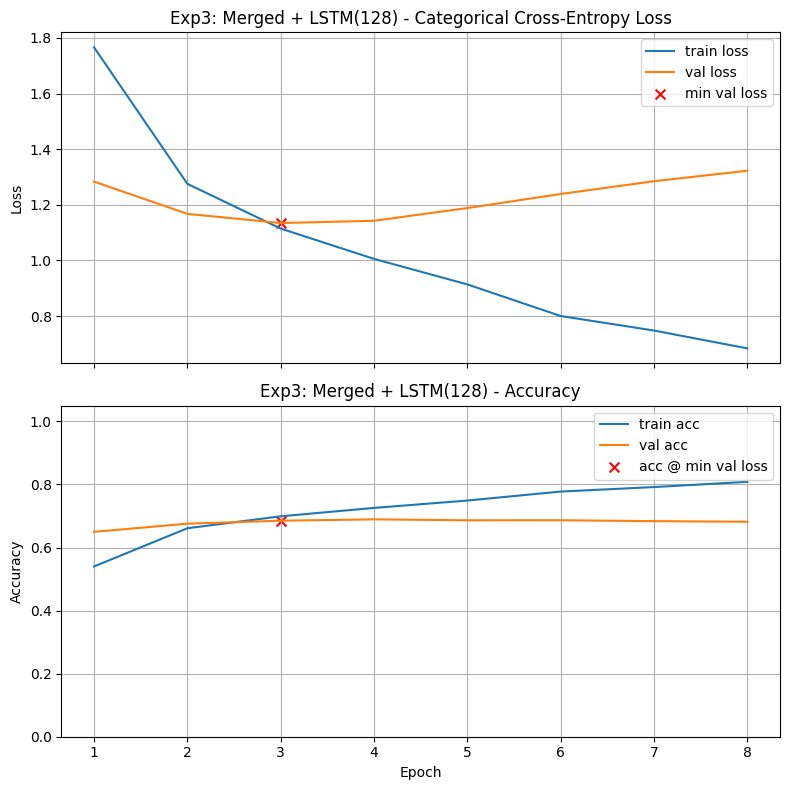


Execution Time: 00:05:00

Final Training Loss:            0.6839
Final Training Accuracy:        0.8084
Final Validation Loss:          1.3226
Final Validation Accuracy:      0.6816
Minimum Validation Loss:        1.1346 (Epoch 3)
Validation Accuracy @ Min Loss: 0.6850

Test Loss: 1.1229
Test Accuracy: 0.6906

Validation-Test Accuracy Gap: 0.005540


In [28]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2,
    min_delta=1e-5, min_lr=1e-8, verbose=1)

train_and_test(
    model_final,
    title="Exp3: Merged + LSTM(128)",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    epochs=20,
    patience=5,
    callbacks=[reduce_lr],
    verbose=1
)

In [29]:
results["M2 GloVe + BiLSTM + Dropout"] = (0.6512, 4)
results["Exp1: Merged Categories + ReduceLR"] = (0.6791, 4)
print_results()

Exp3: Merged + LSTM(128)                	0.6850	3
Exp1: Merged Categories + ReduceLR      	0.6791	4
M2 GloVe + BiLSTM + Dropout             	0.6512	4


Classification Report:
                precision    recall  f1-score   support

ARTS & CULTURE      0.528     0.553     0.540       387
  BLACK VOICES      0.498     0.467     0.482       452
      BUSINESS      0.511     0.513     0.512       593
       COLLEGE      0.692     0.391     0.500       115
        COMEDY      0.564     0.458     0.506       517
         CRIME      0.613     0.591     0.602       340
       DIVORCE      0.806     0.763     0.784       342
     EDUCATION      0.416     0.515     0.460       101
 ENTERTAINMENT      0.686     0.725     0.705      1605
   ENVIRONMENT      0.553     0.197     0.291       132
         FIFTY      0.917     0.079     0.145       140
  FOOD & DRINK      0.772     0.823     0.797       832
     GOOD NEWS      0.314     0.157     0.210       140
         GREEN      0.448     0.561     0.498       262
 HOME & LIVING      0.761     0.750     0.755       416
        IMPACT      0.415     0.269     0.326       346
 LATINO VOICES      0.56

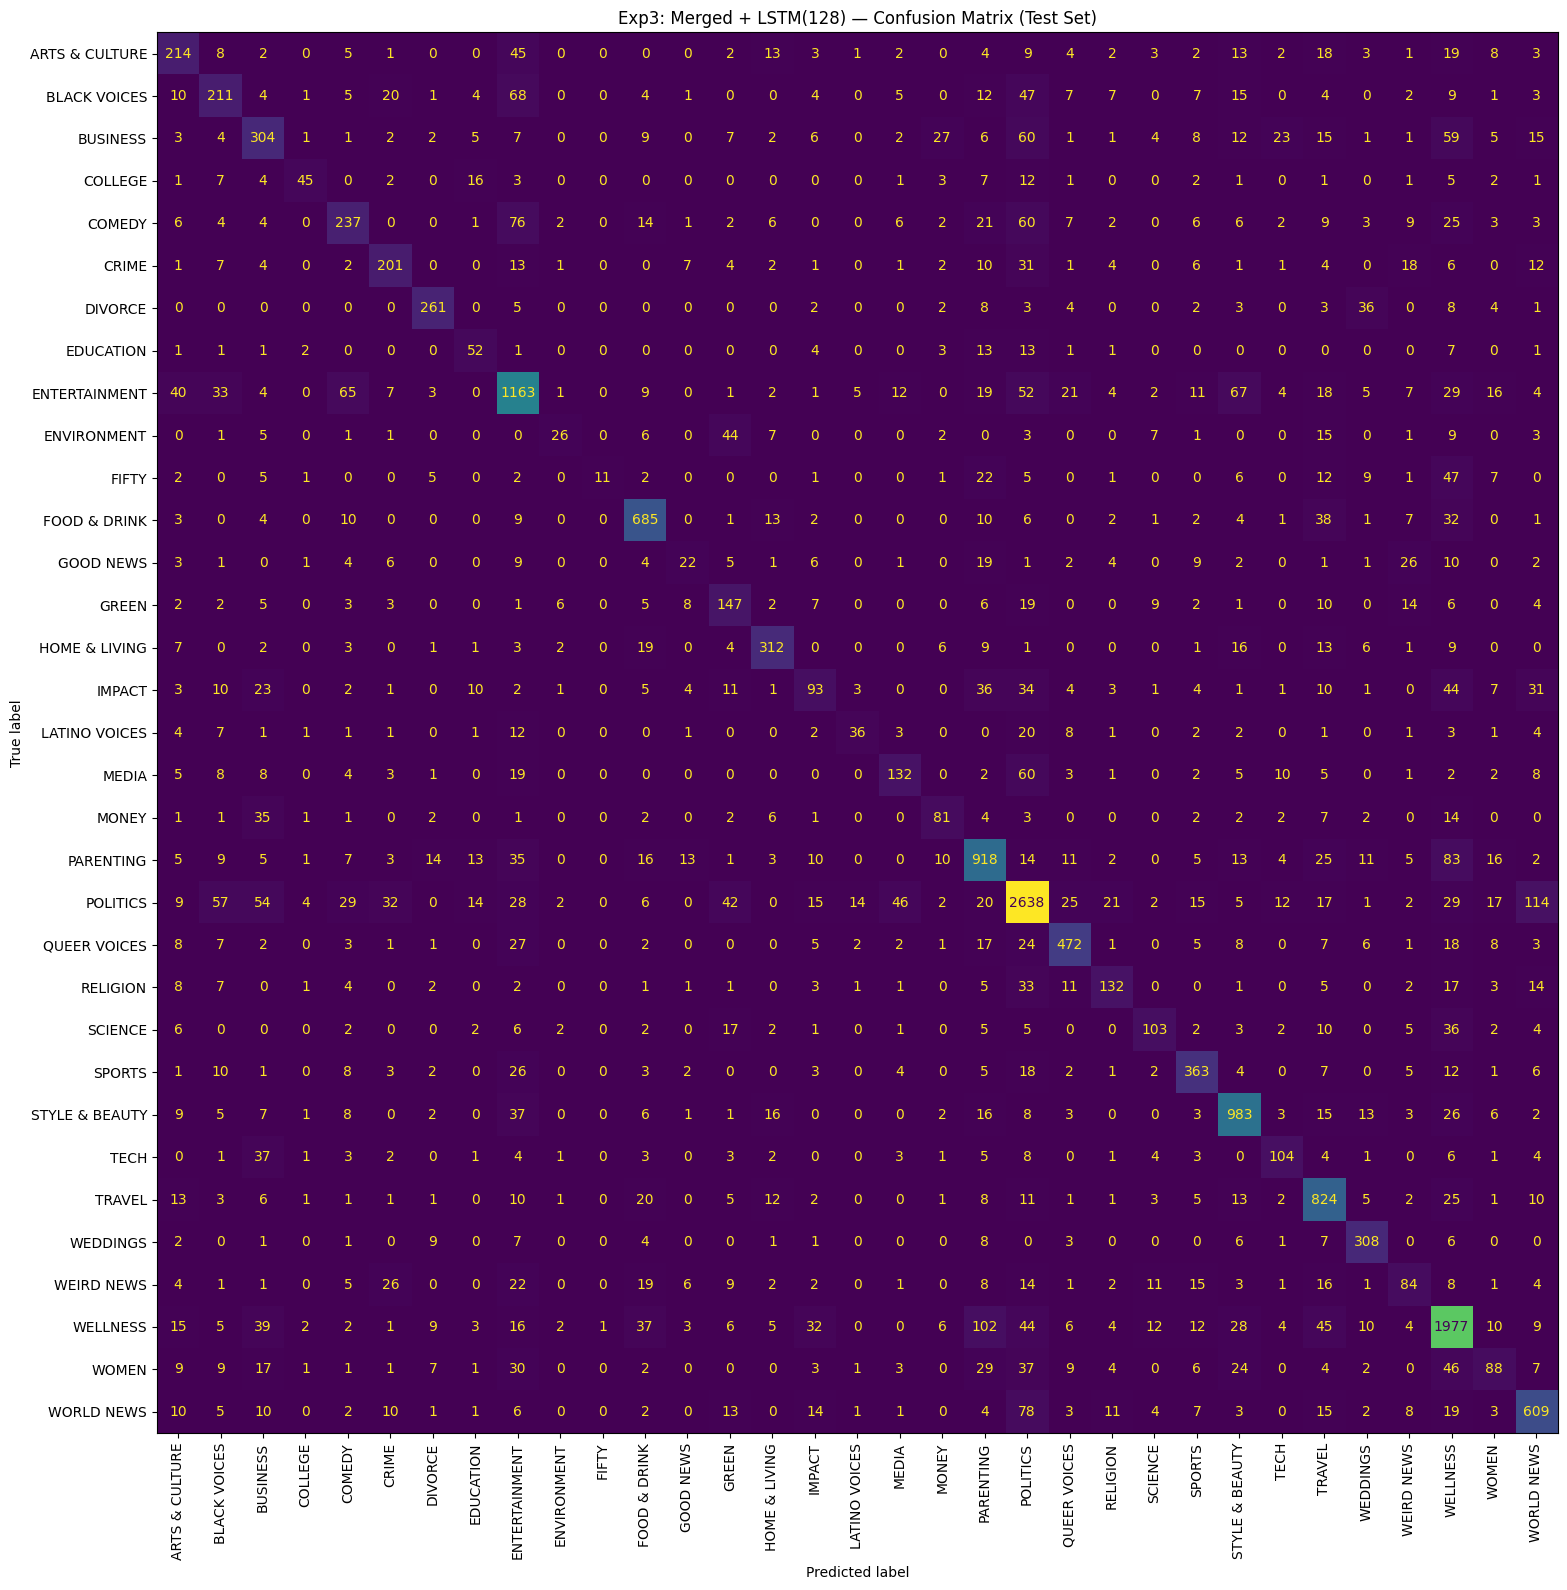

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# A.3 Evaluation
# Get predictions on test set
y_pred_probs = model_final.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# F1 Score Report
print("Classification Report:")
print(classification_report(y_true, y_pred, 
      target_names=unique_categories, digits=3))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=unique_categories)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Exp3: Merged + LSTM(128) — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

## A.3: Evaluation and Visualization

### Evaluation Strategy

The dataset was split 80/10/10 (train/val/test) using stratified sampling 
with random seed 42 to ensure consistent class distribution across all 
subsets. The validation set was used exclusively for monitoring training 
progress and early stopping — the model never trained on it directly. 
The test set was held out completely until final evaluation.

For this dataset, we report the following metrics:
- **Validation Accuracy @ Minimum Validation Loss** — primary training 
  benchmark, consistent across all experiments
- **Test Accuracy** — final held-out performance
- **Macro F1** — treats all 33 classes equally, penalizes ignoring 
  minority classes
- **Weighted F1** — accounts for class frequency, comparable to accuracy
- **Per-class F1** — identifies which categories remain challenging

### Final Test Metrics

| Metric | Value |
|--------|-------|
| Val Accuracy @ Min Val Loss | 68.50% |
| Test Accuracy | 69.06% |
| Macro F1 | 0.566 |
| Weighted F1 | 0.681 |
| Runtime | 5 minutes |

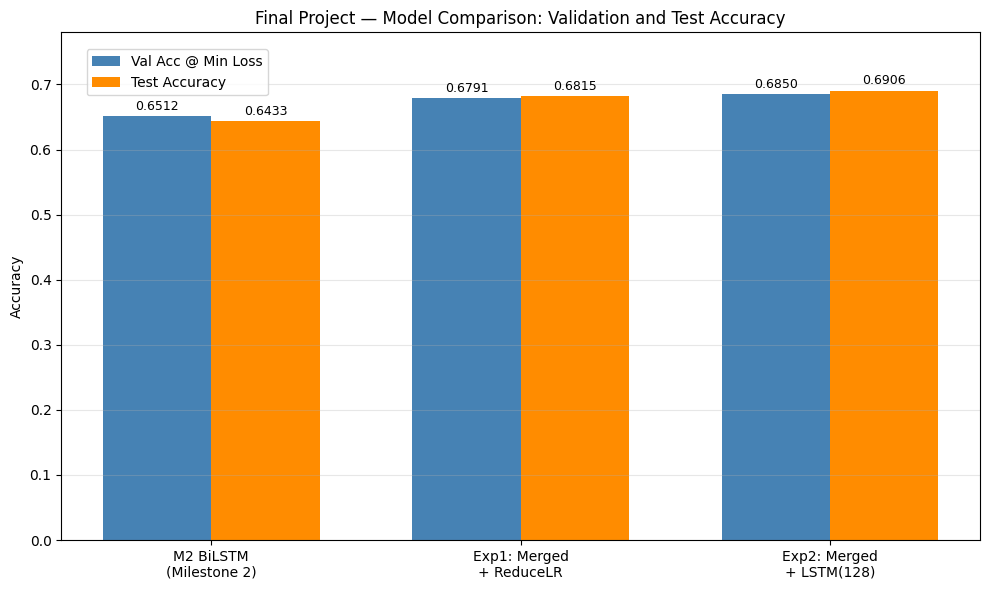


Model                            Val Acc @ Min Loss   Test Acc   Epoch    Runtime
--------------------------------------------------------------------------------
M2 BiLSTM (Milestone 2)                      0.6512     0.6433       4   02:01:43
Exp1: Merged + ReduceLR                      0.6791     0.6815       4   00:03:10
Exp2: Merged + LSTM(128)                     0.6850     0.6906       3   00:05:00


In [ ]:
# Experiment Comparison
import matplotlib.pyplot as plt
import numpy as np

summary = {
    "M2 BiLSTM\n(Milestone 2)":    (0.6512, 0.6433, 4,  "02:01:43"),
    "Exp1: Merged\n+ ReduceLR":    (0.6791, 0.6815, 4,  "00:03:10"),
    "Exp2: Merged\n+ LSTM(128)":   (0.6850, 0.6906, 3,  "00:05:00"),
}

model_names = list(summary.keys())
val_accs    = [v[0] for v in summary.values()]
test_accs   = [v[1] for v in summary.values()]
epochs      = [v[2] for v in summary.values()]
runtimes    = [v[3] for v in summary.values()]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, val_accs,  width, label='Val Acc @ Min Loss', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy',      color='darkorange')

ax.set_ylabel('Accuracy')
ax.set_title('Final Project — Model Comparison: Validation and Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 0.78)
ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98))
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary Table ───────────────────────────────────────────────
models_display = [
    "M2 BiLSTM (Milestone 2)",
    "Exp1: Merged + ReduceLR",
    "Exp2: Merged + LSTM(128)",
]

print(f"\n{'Model':<30} {'Val Acc @ Min Loss':>20} {'Test Acc':>10} {'Epoch':>7} {'Runtime':>10}")
print("-" * 80)
for name, (val, test, ep, rt) in zip(models_display, summary.values()):
    print(f"{name:<30} {val:>20.4f} {test:>10.4f} {ep:>7} {rt:>10}")

## AI Use Disclosure

This project made use of an AI assistant during 
development. It was used to assist with debugging, code structure 
suggestions, and discussing modeling decisions. All code was reviewed, 
understood, and executed by the me. Final decisions on architecture, 
hyperparameters, and analysis were made by me.